In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W1/syllabus.html#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W1/docs/homework_instructions.html) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [2]:
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)

import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer

from sklearn.preprocessing import FunctionTransformer

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.feature_selection import RFE, RFECV

import shap

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

In [3]:
# load both datasets into pandas dataframes
credit_df = pd.read_csv("data/UCI_Credit_Card.csv")
bnb_df = pd.read_csv("AB_NYC_2019.csv")

After analyzing both of the datasets, I have decided to carry out my analysis on the New York Airbnb data set. There were a couple of reasons for this decision, first of which is that I'm more comfortable with building and scoring classification models, and so I'd like to practice developing a regression problem from start to finish. Additionally, there appears to be a lot more variation in the Airbnb data set feature types compared to the credit card data set (which seems to only contain numeric features), and so I think it could be interesting to explore different tactics of predicting the target in the Airbnb problem because of this. However, right off the bat, there appear to be a number of features that won't be helpful at all in predicting the target (ie. id, house_id, and host_name), so I'll have to justify why these should/shouldn't be excluded from my training down the line. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
# split data

# I know this isn't an ideal test split size, but my laptop was struggling especially on the RFECV steps later on, so I increased the test size 
train_df, test_df = train_test_split(bnb_df, test_size = 0.6, random_state = 123) 


In [5]:
# first iteration feature categorization
numeric_features = ["latitude", "longitude", "price", "minimum_nights",
                    "calculated_host_listings_count", "availability_365"]

categorical_features = ["neighbourhood_group", "neighbourhood", "room_type"]

text_features = ["name"]

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

In [6]:
bnb_df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Summary Statistics

1. This reveals a wide range in the price of each available listing, with a mean of 151.53, std of 236.62, and range of \$0 to \$10000. The skew might suggest the need for scaling or transformation later on.
2. Most listings have very short minimum stay requirements, with a median of 3 nights and a mean of 7.09, but the maximum jumps to 1,250 nights, indicating the presence of some extreme outliers or unusual listings that may need to be filtered or capped.
3. The distribution of reviews is heavily skewed, with many listings having very few (median 5) and some having up to 629 reviews. This suggests that popularity is concentrated among a small number of listings.
4. Most hosts have only a few listings, with a median of 1, but some hosts manage as many as 327. This shows that a few professional hosts dominate the platform, which might influence review patterns.
5. The median availability is 45 days, but the mean is 112.53 and some listings are available all year (365 days), reflecting large variation in listing activity and potential seasonality effects.

In [7]:
print("1. Summary of price:")
print(train_df["price"].describe())
print("\n")
print("2. Summary of minimum_nights:")
print(train_df["minimum_nights"].describe())
print("\n")
print("3. Summary of number_of_reviews:")
print(train_df["number_of_reviews"].describe())
print("\n")
print("4. Summary of calculated_host_listings_count:")
print(train_df["calculated_host_listings_count"].describe())
print("\n")
print("5. Summary of availability_365:")
print(train_df["availability_365"].describe())

1. Summary of price:
count    19558.000000
mean       150.967942
std        241.965858
min          0.000000
25%         69.000000
50%        105.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


2. Summary of minimum_nights:
count    19558.000000
mean         7.190050
std         23.477288
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64


3. Summary of number_of_reviews:
count    19558.000000
mean        23.214183
std         43.943843
min          0.000000
25%          1.000000
50%          5.000000
75%         24.000000
max        629.000000
Name: number_of_reviews, dtype: float64


4. Summary of calculated_host_listings_count:
count    19558.000000
mean         6.874527
std         31.883557
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64




| Feature                            | Key Statistics                                       | Interpretation / Insight                                                                                                                                                                                              |
| ---------------------------------- | ---------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **price**                          | Mean = $153, Max = $10,000, Std = 240 | Prices vary drastically — most listings are moderately priced in the range of $100 to $200, but a few really expensive listings skew the average upward. The large standard deviation indicates strong right skew. |
| **minimum_nights**                 | Mean = 7.0, Max = 1250                   | Most hosts require short stays (1-5 nights), but some impose extremely long minimums (up to 1250 days), likely due to long-term rentals or misentered data. These outliers may need to be capped or log-transformed down the line.                |
| **number_of_reviews**              | Mean = 23.3, Max = 629                   | The average listing has relatively few reviews, indicating that many listings are either new or aren't booked/reviewed frequently. A few listings dominate with hundreds of reviews, suggesting popularity imbalance.                |
| **calculated_host_listings_count** |  Mean = 7.14, Max = 327                   | Most hosts manage only one or a few properties, but some manage hundreds, indicating the presence of large-scale commercial hosts alongside individual homeowners within this dataset.                                                      |
| **availability_365**               | Mean = 113 days, Max = 365                  | Many listings are available for only part of the year - possibly rented long-term off-platform or seasonally listed (ie. homeowner lives in the unit for certain months of the year and rents the rest of the year. This could be an important consideration for why certain units are more popular, and perhaps removing outliers might be necessary.                           |


In [8]:
for feature in categorical_features:
    print(f"\n--- {feature} ---")
    print(bnb_df[feature].value_counts())


--- neighbourhood_group ---
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

--- neighbourhood ---
neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Fort Wadsworth           1
Richmondtown             1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

--- room_type ---
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


### Visualization #1 

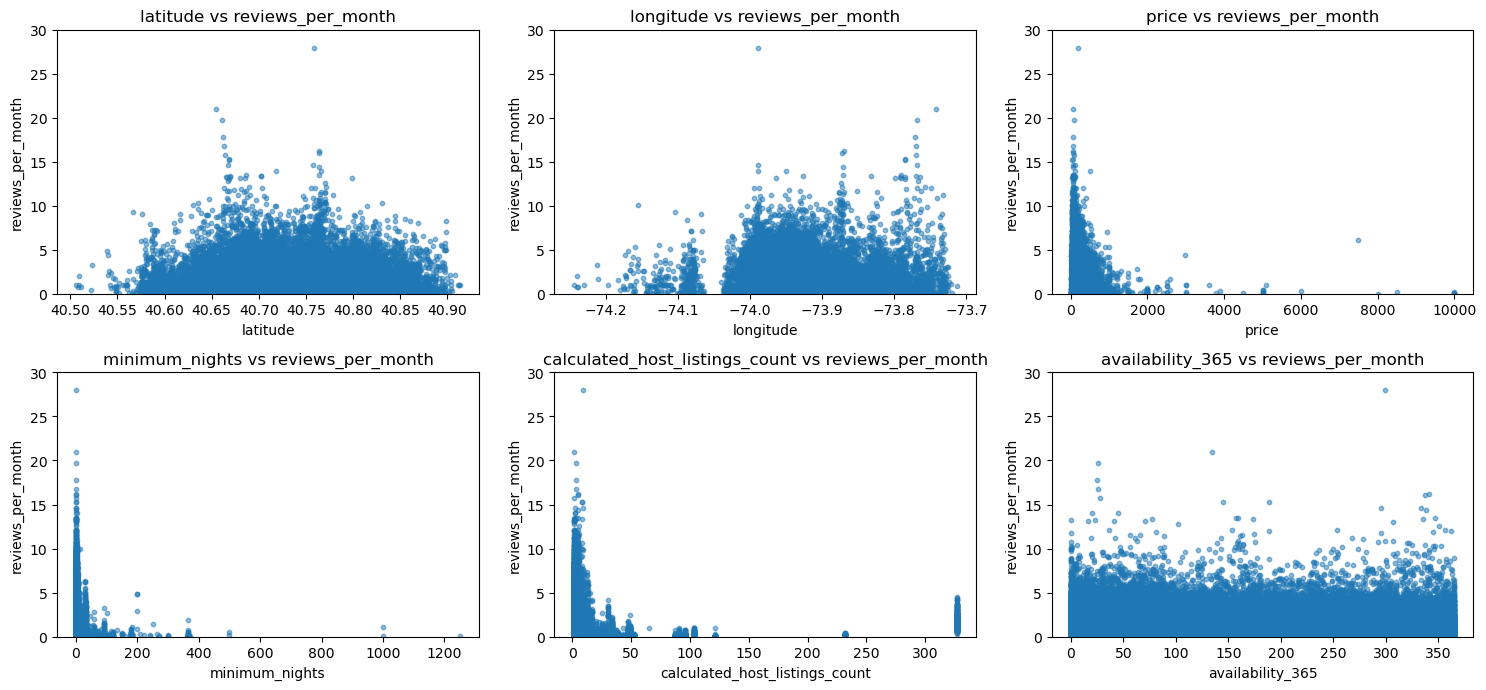

In [9]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    plt.scatter(bnb_df[feature], bnb_df["reviews_per_month"], alpha=0.5, s=10)
    plt.xlabel(feature)
    plt.ylabel("reviews_per_month")
    plt.title(f"{feature} vs reviews_per_month")
    plt.ylim(0,30)

plt.tight_layout()
plt.show()

- `id`: This feature's reviews_per_month appears quite uniform across all values of id, which makes sense in the context of the problem, as we don't expect this feature to be very predictive of our target.  
- `host_id`: Also appears quite uniform across all values, likely not very predictive.  
- `latitude`: There is perhaps a trend where reviews_per_month peaks between a latitude value of 40.70 and 40.75.   
- `longitude`: There appears to be a similar peaking distribution in this feature with a large gap between longitude -74.1 and 74.0 (perhaps this is a region where there is water?).   
- `price`: The distribution of price vs reviews_per_month is quite right-skewed. There are a lot more reviews for cheaper houses, possibly because there is a larger market for these listings.    
- `minimum_nights`: Like price, there are a lot more reviews per month when listings have low minimum nights, which makes sense as having the ability for people to filter in and out more frequently would allow for more reviews to be written on a monthly basis.  
- `number_of_reviews`: This feature looks the very predictive. We see a clear trend where increases in the total number_of_reviews correlates with more reviews_per_month. This makes logical sense why the two would be correlated, although it may not make sense for us to include this feature (see initial observations below).    
- `calculated_host_listings_count`: This is clearly right-skewed as well. Perhaps individuals searching for an airbnb prefer the care and attention of a host with fewer listings to tend to, and so this could be an important feature to consider.   
- `availability_365`: Surprisingly this feature does not appear to influence the number of reviews per month. We might expect higher listing availability to coincide with more reviews per month, however - at least from the scatterplot - this does not appear to be the case just yet.

### Visualization #2

<Figure size 800x400 with 0 Axes>

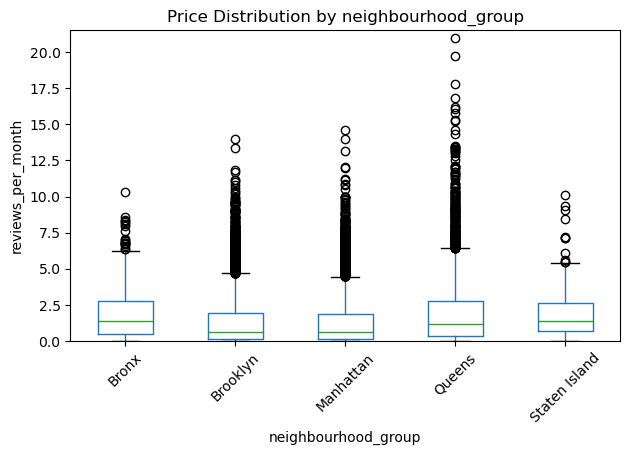

<Figure size 800x400 with 0 Axes>

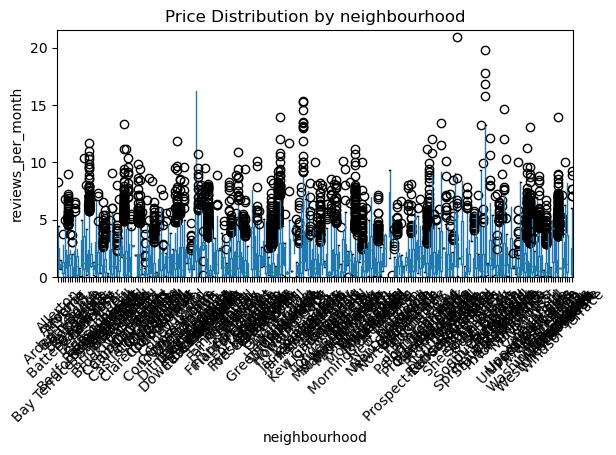

<Figure size 800x400 with 0 Axes>

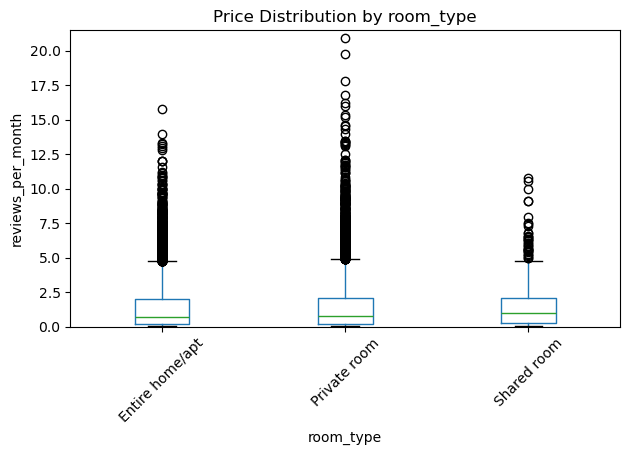

In [10]:
for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    bnb_df.boxplot(column= "reviews_per_month", by=feature, grid=False)
    plt.title(f"Price Distribution by {feature}")
    plt.suptitle("")  
    plt.ylim(0, 21.5)
    plt.xlabel(feature)
    plt.ylabel("reviews_per_month")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

- `neighbourhood_group`: This is looking at grand neighbourhood groupings in New York. While there are no significant differences between groups, there is definitely a trend where certain neighbourhood groupings (ie. Bronx, Queens, Staten Island) have a higher mean number of reviews per month than other neighbourhood groupings (ie. Manhattan, Brooklyn).   
- `neighbourhood`: From the plot, we can see that there is a substantial number of unique neighbourhoods in our data set. While it's hard to decipher trends from this plotting method off the bat, I included it here to show that there are definitely some important trends pertaining to neighbourhoods that an ML model might be able to learn patterns from. In other words, the number_of_reviews per neighbourhood is not uniform, some neighbourhoods clearly coincide with more reviews per month - perhaps those in more "touristy" areas, while others coincide with less.   
- `room_type`: The mean number of reviews per month is the largest in shared rooms compared to private rooms/entire home/apt listing room types. This makes sense, as shared rooms generally would be expected to have a larger throughput rate of visitors (ie. more independent parties staying in the airbnb ==> more monthly reviews on average).

### Initial Observations

- In the context of our problem - trying to predict the reviews_per_month as a proxy for the popularity of a listing and to gauge how popular future listings might be before they are posted - there are some features that do not make sense to keep.
    - `ID`: This is a unique identifier for each listing and does not contain any meaningful information about the characteristics or popularity of a listing. Including it would only add noise to the model without improving predictive power.
    - `host_name/id`: Similar to id, these are unique identifiers for each host and do not provide meaningful information about the popularity of a listing. Including them could cause the model to overfit to specific host names or hosts in the training set, which could introduce noise and would not generalize to new or future hosts. Additionally, encoding it would create many sparse features without improving how generalizable the model is, and so I'm opting to drop these columns. 
    - `number_of_reviews`: From the problem description, because our goal is to gauge the popularity of **future listings** that have not yet been listed, we should assume that all listings will have zero reviews when deployed, and so it would be illogical to have our ML model learn patterns from the number of reviews that a given listing already has. This logic is derived from Lecture 10, iClicker 10.1, where we were predicting house_value and decided price_per_square_foot would not be a good feature to include, given we likely won't have access to this during deployment.
    - `last_review`: Similar rationale as number_of_reviews, it would not make sense to include this when our goal is to predict on brand new/unpublished listings.
- There exists missing values, particularly in our target, `reviews_per_month`, and `last_review`. There are also an insignificant amount of empty values in `name` and `host_name`. Since we plan to drop `last_review` and `host_name`, we won't really need to worry about them, but for `reviews_per_month` and `name`, we'll need to devise a strategy down the road for how we will handle such cases.
- Some features (ie. `neighbourhood`, `room_type`) appear to have high predictive power
- Some features (ie. `availability_365`) appear to have low predictive power, but we should not assume that just because they don't appear to contain meaningful or predictive patterns that they are useless - they still might be useful after transforming them or engineering them in conjunction with other features.

### Metric Choice and Justification

For this regression problem, r2 was chosen as the primary evaluation metric. r2 provides a clear and interpretable measure of how well the model explains the variance in the target variable relative to a simple mean predictor. In other words, it captures how much of the variation in outcomes is accounted for by the features in the model.

Compared to RMSE and MSE, which are scale-dependent and expressed in the same units (or units squared) as the target, r2 offers a unitless and standardized interpretation, making it easier to compare model performance across different datasets or transformations. MAPE, on the other hand, can be unreliable when target values are close to zero and can disproportionately penalize small denominators, making this not as ideal for our dataset.

Since the goal in this project is to assess how effectively the model captures patterns and explains variability, r2 is the most suitable and interpretable choice.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

For engineered features, I have created 2 features that I believe are interesting and might help improve our model's ability to predict our target class, `reviews_per_month`.
      
1. Availability-to-Minimum-Nights Ratio: A new column that holds the ratio of days available per year to the minimum number of nights required for a booking
    - Why: Listings that are available many days per year and allow short minimum stays are likely easier for guests to book. This flexibility could lead to more bookings and therefore more reviews per month, making it a potentially strong predictor of popularity.
  
2. Listing Name length: A new column that holds the length of each listing's title length
    - Why: One of the first things an individual looking for a place to stay might see is the listing title. While holding keywords in your title could certainly be indicative of listing popularity (as we'll analyze with CountVectorizer), the length of the title might also be indicative of popularity. Generally, more descriptive/longer titles might attract more viewers, allowing for better click-through rates, however excessively long titles might detract viewers. And so it's possible there is a middle-ground that could be optimized for new listings to maximize their viewer retention and ultimately their reviews per month.

In [11]:
train_df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,1.955800e+04,1.955800e+04,19558.000000,19558.000000,19558.000000,19558.000000,19558.000000,15614.000000,19558.000000,19558.000000
mean,1.883431e+07,6.652727e+07,40.729137,-73.951938,150.967942,7.190050,23.214183,1.355881,6.874527,112.248901
std,1.100645e+07,7.806691e+07,0.054629,0.046189,241.965858,23.477288,43.943843,1.640878,31.883557,131.302396
min,2.539000e+03,2.438000e+03,40.507080,-74.242850,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.303320e+06,7.656499e+06,40.690080,-73.982750,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.936397e+07,3.028359e+07,40.722985,-73.955405,105.000000,3.000000,5.000000,0.700000,1.000000,44.000000
75%,2.901352e+07,1.053641e+08,40.763388,-73.936120,175.000000,5.000000,24.000000,2.000000,2.000000,224.000000
max,3.648543e+07,2.743115e+08,40.912340,-73.712990,10000.000000,1250.000000,629.000000,20.940000,327.000000,365.000000


In [12]:
# Availability Ratio
train_df["availability_ratio"] = train_df["availability_365"] / train_df["minimum_nights"]
test_df["availability_ratio"] = test_df["availability_365"] / test_df["minimum_nights"]

# Name Word Length
train_df["name_word_length"] = train_df["name"].apply(lambda x: len(str(x).split()))
test_df["name_word_length"] = test_df["name"].apply(lambda x: len(str(x).split()))

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

For this dataset, I noticed a significant number of NaN values in the target, `reviews_per_month`. When deciding how to handle these cases, I noticed that they almost all had 0 `number_of_reviews` as well. As such, if a listing's `number_of_reviews` is 0 and its `reviews_per_month` is NaN, I will impute the `reviews_per_month` as 0. I believe that this approach is reasonable, and will ensure I am not unjustly removing all actual 0 `review_per_month` examples in my data set.

In [13]:
# impute NaN reviews_per_month as 0 if number_of_reviews is also 0
dfs = [train_df, test_df] 

for i, df in enumerate(dfs): 
    # fill NaN reviews_per_month rows with 0 
    df["reviews_per_month"] = df["reviews_per_month"].fillna(0) 
    
    # keep only rows where reviews_per_month and number_of_reviews are 0, else drop
    df = df[(df["number_of_reviews"] == 0) & (df["reviews_per_month"] == 0)]

In [14]:
# remove NaN name values from both train_df, test_df 
train_df = train_df.dropna(subset=["name"]) 
test_df = test_df.dropna(subset=["name"])

# apply log1p to the target to help correct distribution skew
train_df["log_reviews_per_month"] = np.log1p(train_df["reviews_per_month"])
test_df["log_reviews_per_month"] = np.log1p(test_df["reviews_per_month"])  

In [15]:
# splitting train and test dfs into X, y 
X_train = train_df.drop(columns=["reviews_per_month", "log_reviews_per_month"])
X_test = test_df.drop(columns=["reviews_per_month", "log_reviews_per_month"])

y_train = train_df["reviews_per_month"]
y_test = test_df["reviews_per_month"]

y_train_transformed = train_df["log_reviews_per_month"]
y_test_transformed = test_df["log_reviews_per_month"]

In [16]:
# updated feature categorization
numeric_features = ["latitude", "longitude", "price", "minimum_nights",
                    "calculated_host_listings_count", "availability_365"]

engineered_numeric_features = ["availability_ratio", "name_word_length"]

categorical_features = ["neighbourhood_group", "neighbourhood", "room_type"]

text_features = ["name"]

drop_features = ["id", "host_id", "number_of_reviews", "host_name", "last_review"]

In [17]:
# text transformer without FunctionTransformer
text_transformer = make_pipeline(
    CountVectorizer(stop_words="english")
)

# modify preprocessor — note how we directly pass the text column name here
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features + engineered_numeric_features),
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
    (text_transformer, "name"),  # directly specify the column name here
    ("drop", drop_features)
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [18]:
# create baseline pipeline with our preprocessor and DummyRegressor
baseline_pipe = make_pipeline(
    preprocessor,
    DummyRegressor()
)

# run cv on this baseline with r2 and rmse scoring metrics
baseline_r2_scores = cross_val_score(baseline_pipe, X_train, y_train_transformed, cv = 5, scoring = "r2")
baseline_rmse_scores = cross_val_score(baseline_pipe, X_train, y_train_transformed, cv = 5, scoring = "neg_root_mean_squared_error")

In [19]:
# convert scores to a pandas df
baseline_scores_df = pd.DataFrame({
    "R2": baseline_r2_scores,
    "RMSE": baseline_rmse_scores
})
baseline_scores_df

,R2,RMSE
0,-0.000096,-0.571190
1,-0.000011,-0.574803
2,-0.000361,-0.578305
3,-0.000010,-0.583254
4,-0.001301,-0.563675


In [20]:
print("Mean baseline r2 scores:", baseline_r2_scores.mean())
print("Mean baseline rmse scores:", baseline_rmse_scores.mean())

Mean baseline r2 scores: -0.00035593881802107317
Mean baseline rmse scores: -0.5742453205232778


I used DummyRegresor with both r2 and rmse regression scoring metrics to gauge my baseline scores under 10-fold cv.  
Results: 
- **Mean r2: -0.0004** → Essentially 0, meaning the model explains none of the variance in the target. 

- **Mean RMSE: 1.61 (absolute value)** → On average, the baseline model’s predictions of `reviews_per_month` are off by ~0.57 log1p reviews.

Interpretation:
These scores provide a reference point; any real model should achieve r2 > 0 and/or RMSE < 1.61 to be considered better than this naive baseline.


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

In [21]:
alphas = [0.01, 0.1, 1.0, 10, 100, 1000]
lr_res = {
    "alpha": [],
    "mean_train_r2": [],
    "mean_val_r2": [],
    "std_val_r2": [],
    "mean_train_rmse": [],
    "mean_val_rmse": [],
    "std_val_rmse": [],
}

for alpha in alphas:
    lr_pipe = make_pipeline(preprocessor, Ridge(alpha=alpha))
    
    lr_scores = cross_validate(
        lr_pipe,
        X_train,
        y_train_transformed,
        scoring=["r2", "neg_root_mean_squared_error"],
        cv=5,
        return_train_score=True
    )
    
    lr_res["alpha"].append(alpha)
    lr_res["mean_train_r2"].append(lr_scores["train_r2"].mean())
    lr_res["mean_val_r2"].append(lr_scores["test_r2"].mean())
    lr_res["std_val_r2"].append(lr_scores["test_r2"].std())
    
    lr_res["mean_train_rmse"].append(lr_scores["train_neg_root_mean_squared_error"].mean())
    lr_res["mean_val_rmse"].append(lr_scores["test_neg_root_mean_squared_error"].mean())
    lr_res["std_val_rmse"].append(lr_scores["test_neg_root_mean_squared_error"].std())

lr_res_df = pd.DataFrame(lr_res)
lr_res_df


,alpha,mean_train_r2,mean_val_r2,std_val_r2,mean_train_rmse,mean_val_rmse,std_val_rmse
0,0.01,0.430589,0.046041,0.017027,-0.433316,-0.560705,0.004324
1,0.10,0.428681,0.078879,0.017907,-0.434041,-0.550962,0.004238
2,1.00,0.394570,0.152030,0.017722,-0.446810,-0.528624,0.004060
3,10.00,0.299385,0.193273,0.013187,-0.480652,-0.515625,0.003140
4,100.00,0.227779,0.194935,0.010676,-0.504618,-0.515108,0.003618
5,1000.00,0.179413,0.171185,0.008744,-0.520181,-0.522667,0.004591


| **Observation**                           | **Explanation (adjusted for log-transformed target)**                                                                                                                                                                                                                                                                                                           |
| ----------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Train vs. Validation r2**               | As `alpha` increases from 0.01 → 1000, train r2 decreases (0.43 → 0.18) while validation r2 improves initially (0.04 → 0.19) and then slightly declines (to 0.17). This confirms the expected bias–variance trade-off, where moderate regularization improves generalization by reducing overfitting.                                                       |
| **Train vs. Validation RMSE (log-space)** | Validation RMSE improves (becomes less negative, meaning smaller absolute RMSE) up to α = 100 (RMSE 0.515), then plateaus. Because RMSE is computed on `np.log1p(y)`, this indicates more stable predictions on a log scale - smaller multiplicative errors when transformed back to original space.                                                 |
| **Interpretation in original units**      | Since I applied a log transform, a difference of 0.5 in log-space implies even small improvements in log-RMSE translate to meaningful accuracy gains in the original target space.                                                                          |
| **Standard deviation trends**             | Both `std_val_r2` and `std_val_rmse` shrink with higher α (e.g., 0.017 → 0.009), showing that stronger regularization yields more consistent performance across folds. This is indicative of improved model stability.                                                                                                                                             |
| **Optimal α region**                      | α = 10–100 achieves the best validation r2 (~0.195) and lowest validation RMSE (0.515), representing the best balance between bias and variance. Larger alphas (1000) start underfitting, as both R² and RMSE degrade slightly.                                                                                                                           |
| **Model performance summary**             | Even after transformation, overall r2 (~0.2) indicates the model captures only modest variance in the target. This suggests the relationship between features and reviews_per_month might not be best represented through a linear model. Nonlinear models (e.g., Random Forests, Gradient Boosting, SVR with RBF kernel) could capture more complex interactions and improve performance (next section) |


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

### Key Takeaways

`Linear Model`: Limited by its simplicity. Moderate alpha improves bias-variance trade-off, but cannot capture nonlinearities in the data.

`SVR`: Captures more structure than linear models, benefiting from its nonlinear kernel. Validation r2 improves up to 0.33
, showing it can handle some nonlinear relationships, however validation r2 and train r2 are still quite low, suggesting underfitting. 

`Random Forest`: High train r2 compared to a lower validation r2 (0.89 vs 0.37 respectively) suggests overfitting on the training set. Still, this model's validation score is better than both the linear and SVR models. 

`GradientBoost`: Performs better than the SVR model and slightly better than the Random Forest model in validation r2 score, but is still not incredibly high. Its low variance across folds suggests stable but limited learning. Training score and validation score around 0.44 - 0.41 suggests this model may be underfitting.


All models outperform the simplest linear model, with GradientBoost performing the best, followed by Random Forest then SVR. Future improvements could include hyperparameter tuning, reconsideration of feature engineering, or stacking models to reduce overfitting/underfitting and boost validation r2.

In [22]:
# SVR model

svr_res = {
    "mean_train_r2": [],
    "mean_val_r2": [],
    "std_val_r2": [],
}

svr_pipe = make_pipeline(
    preprocessor, SVR(kernel = "rbf"))

svr_scores = cross_validate(svr_pipe, X_train, y_train_transformed, scoring="r2", cv=5, return_train_score=True)

svr_res["mean_train_r2"].append(svr_scores["train_score"].mean())
svr_res["mean_val_r2"].append(svr_scores["test_score"].mean())
svr_res["std_val_r2"].append(svr_scores["test_score"].std())

svr_res_df = pd.DataFrame(svr_res)
svr_res_df

,mean_train_r2,mean_val_r2,std_val_r2
0,0.666352,0.33499,0.012999


In [23]:
# random forest model 

rf_res = {
    "mean_train_r2": [],
    "mean_val_r2": [],
    "std_val_r2": [],
}

rf_pipe = make_pipeline(
    preprocessor, RandomForestRegressor(n_estimators = 10, random_state = 1234, n_jobs = -1)
)

rf_scores = cross_validate(rf_pipe, X_train, y_train_transformed, scoring = "r2", cv = 5, return_train_score = True)

rf_res["mean_train_r2"].append(rf_scores["train_score"].mean())
rf_res["mean_val_r2"].append(rf_scores["test_score"].mean())
rf_res["std_val_r2"].append(rf_scores["test_score"].std())

rf_res_df = pd.DataFrame(rf_res)
rf_res_df

,mean_train_r2,mean_val_r2,std_val_r2
0,0.890933,0.370504,0.01927


In [24]:
# gradient boost model

gb_res = {
    "mean_train_r2": [],
    "mean_val_r2": [],
    "std_val_r2": [],
}

gb_pipe = make_pipeline(
    preprocessor, GradientBoostingRegressor()
)

gb_scores = cross_validate(gb_pipe, X_train, y_train_transformed, scoring = "r2", cv = 5, return_train_score = True)


gb_res["mean_train_r2"].append(gb_scores["train_score"].mean())
gb_res["mean_val_r2"].append(gb_scores["test_score"].mean())
gb_res["std_val_r2"].append(gb_scores["test_score"].std())

gb_res_df = pd.DataFrame(gb_res)
gb_res_df

,mean_train_r2,mean_val_r2,std_val_r2
0,0.438924,0.405177,0.015225


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

I incorporated an RFECV step (with a Ridge regression model, α = 100) directly into the pipeline to perform feature selection within each cross-validation fold. 

Model performance was compared before and after integrating RFECV using 5-fold cross-validation:

Before feature selection: Mean CV r2 = 0.1949

After feature selection: Mean CV r2 = 0.1946

Feature selection did not lead to a meaningful improvement in model performance (a negligible change of –0.0003). This suggests that the original Ridge regression model, combined with preprocessing, was already robust to redundant or noisy features. While there is an argument to be made that incorporating the feature selection into my workflow may allow for improved interpretability by cutting out unhelpful features and noise, the substantial increase in computation time without improving generalization ultimately led to me deciding that the benefits do not outweigh the costs.

Therefore, I will omit RFECV-based feature selection from subsequent exercises to maintain computational efficiency and model simplicity, as it does not enhance predictive performance in this case.

In [25]:
# before feature selection 
ridge_pipe = make_pipeline(preprocessor, Ridge(alpha=100))

cv_results_before_selection = cross_validate(
    ridge_pipe, X_train, y_train_transformed, cv=5, scoring="r2", n_jobs=-1
)
mean_r2_before_selection = cv_results_before_selection["test_score"].mean()
print(f"Mean CV r2 before feature selection: {mean_r2_before_selection:.4f}")

Mean CV r2 before feature selection: 0.1949


In [26]:
# after feature selection
fs_pipe = make_pipeline( 
    preprocessor,
    RFECV(Ridge(alpha=100), cv=5, n_jobs=-1), 
    Ridge(alpha=100)
)

# evaluate full pipeline with CV (leakage-free)
cv_results_fs = cross_validate(
    fs_pipe, X_train, y_train_transformed, cv=5, scoring="r2", n_jobs=-1
)

mean_r2_fs = cv_results_fs["test_score"].mean()
print(f"Mean CV r2 with feature selection: {mean_r2_fs:.4f}")

Mean CV r2 with feature selection: 0.1946


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

| **Model**             | **Best Parameters (Optimized)**   | **Best Mean r2** | **Baseline Mean r2** | **Change** |
| --------------------- | --------------------------------- | ---------------- | -------------------- | ---------- |
| **Ridge Regression**  | α = 109.0, max_features = 2091    | 0.194            | 0.194                   | —          |
| **Random Forest**     | n_estimators = 88, max_depth = 29 | 0.360            | 0.371                | slight decrease  |
| **Gradient Boosting** | n_estimators = 85, max_depth = 10 | 0.366            | 0.405                | slight decrease |
| **SVR**               | — (not tuned due to runtime)      | 0.335            | 0.335                | —          |

Hyperparameter optimization led to mixed outcomes.

Ridge Regression achieved an r2 of 0.19, which matched our best model from manual hyperparameter tuning in question 7.

Random Forest and Gradient Boosting both showed minor decreases in validation performance after tuning, suggesting default hyperparameters were already near-optimal. Another possible reason is that I had to set n_iter (the number of random combinations attempted) to 25 due to computational demand. This likely was not comprehensive enough to truly identify the most optimal hyperparameters. Given more computational power, this could be elevated to increase our chances of finding the most optimal hyperparameter values with improved cv scores. Alternatively, GridSearchCV could be employed if I wanted to perform a very comprehensive search through all possible combinations of hyperparameters in my models.

I did not perform hyperparameter optimization on my SVR model. As per Piazza post @366, given this model was not our top performing model, and that RandomSearchCV takes ~1-3 hours to run on the SVR model (also generating lots of heat in my laptop), I opted to avoid optimization on this model.

Overall, optimization did not substantially improve performance, likely due to dataset noise and strong baseline generalization, and a non-comprehensive search, but it provided insight into model sensitivity and parameter effects.


In [27]:
# Linear Regression (Ridge) Hyperparameter Optimization
param_dist = {
    "ridge__alpha": uniform(0.1, 1000),
    "columntransformer__pipeline__countvectorizer__max_features": randint(100, 2500)
}

rs_lr = RandomizedSearchCV(
    lr_pipe,
    param_distributions = param_dist,
    n_iter = 25,
    scoring = "r2",
    cv = 5,
    n_jobs = -1,
    random_state = 123
)

rs_lr.fit(X_train, y_train_transformed)

print("Best LR parameters (RS):", rs_lr.best_params_)
print("Best LR mean r2 score:", rs_lr.best_score_)


Best LR parameters (RS): {'columntransformer__pipeline__countvectorizer__max_features': 2091, 'ridge__alpha': np.float64(109.02895223970899)}
Best LR mean r2 score: 0.19432452917483733


In [28]:
# Random Forest Hyperparameter Optimization

param_dist = {  
    "randomforestregressor__n_estimators": randint(10, 100),
    "randomforestregressor__max_depth": randint(10, 30),
}

rs_rf = RandomizedSearchCV(
    rf_pipe,
    param_distributions = param_dist,
    n_iter = 25,
    scoring = "r2",
    cv = 5,
    n_jobs = -1,
    random_state = 123
)
rs_rf.fit(X_train, y_train)

print("Best RandomForest parameters (RS):", rs_rf.best_params_)
print("Best RandomForest r2 score:", rs_rf.best_score_)                 

Best RandomForest parameters (RS): {'randomforestregressor__max_depth': 29, 'randomforestregressor__n_estimators': 88}
Best RandomForest r2 score: 0.3599036445790692


In [29]:
# Gradient Boosting Hyperparameter Optimization
param_dist_gb = {
    "gradientboostingregressor__n_estimators": randint(10, 100),
    "gradientboostingregressor__max_depth": randint(10, 50),
}

rs_gb = RandomizedSearchCV(
    gb_pipe,
    param_distributions = param_dist_gb,
    n_iter = 25,
    scoring = "r2",
    cv = 5,
    n_jobs = -1,
    random_state = 123
)

rs_gb.fit(X_train, y_train)

print("Best GradientBoosting parameters (RS):", rs_gb.best_params_)
print("Best GradientBoosting r2 score:", rs_gb.best_score_)

Best GradientBoosting parameters (RS): {'gradientboostingregressor__max_depth': 10, 'gradientboostingregressor__n_estimators': 85}
Best GradientBoosting r2 score: 0.3650013753874446


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

I chose to examine feature importance using SHAP for my GradientBoostRegression non-linear model.

`Bar Plot`: This plot illustrates the average absolute SHAP value for each feature, representing how substantially each feature contributes to the model's predictions on average across all samples. 
    - Here, longer bars are indicative of a more important feature - that is, a feature that plays a larger role within the model in predicting the target irrespective of direction (ie. positive or negative influence). 
    - From this plot, we can see that the features that were found to be the most important for dictating the prediction were the `availability_ratio`, `minimum_nights`, `availability_365`, `price`, and `room_type_Entire home/apt`. I think this is quite logical in the context of the problem, given we'd expect things like price and availability (ie. how easy the airbnb is to book) to play a large role in dictating how many reviews a listing would have, and by extension how popular the listing is.
    - Conversely, some features that were found to be relatively not as important include whether the listing `name` contained the word "cozy", "furnished", or "central".
    - It's also important to note that this bar plot only shows the top contributing features, and not all of the features that the model used during training to predict the target, as there are hundreds (if not thousands) of features as a result of the BOW approach used to numerically encode the listing `name`, as well as the OneHotEncoder approach for the neighbourhoods. 

`Summary Plot`: While the bar plot provides a useful overview of which features the model relies on most to predict the target, it does not convey directionality — that is, whether a feature increases or decreases the predicted value. The SHAP summary plot addresses this by showing both the magnitude and direction of each feature’s influence. Each dot represents a SHAP value for a given feature and sample, centered around 0, where positive SHAP values indicate a positive contribution to the prediction, while negative values indicate a negative contribution. The color gradient adds another layer of interpretation, where red points represent high feature values, and blue points represent low feature values. Thus, if a feature shows a cluster of red points above 0, it means that higher values of that feature tend to increase the model’s prediction. Conversely, a concentration of red points below 0 indicates that higher values of that feature tend to decrease the prediction.
    - From the plot, we can see that `availability_ratio`, `room_type_Entire home/apt`, and `name_word_length` are positively associated with `reviews_per_month`, meaning that higher values for these features increase predicted review activity. In contrast, `minimum_nights` and `price` are negatively associated with the target, meaning that higher prices or longer minimum stays reduce predicted review frequency.
    - Overall, these results are logical, as listings that are more available, have longer or more descriptive titles, and are entire homes are likely to attract more reviews, while high prices or minimum-night requirements tend to deter bookings and, by extension, reviews.

`Waterfall Plot`: Finally, we can use a waterfall plot to exemplify how a model uses different features to make a prediction for a specific example. The plot gives us an E[f(x)] as well as an f(x) value, where E[f(x)] is the expected value of the model output (i.e the average model prediction across the entire dataset or the “baseline prediction”). This can be interpreted as what the model would predict before seeing any specific featurses of this individual example.f(x) is the the model’s predicted value for the specific instance being explained (after accounting for all feature contributions).Here, E[f(x)] is 0.541, while our example's f(x) is 0.87, which means that the combination of feature values for this particular example increased the model’s prediction by +0.329 relative to the average. Looking at the features that were most significantly responsible for this disparity, we can see that `availability_ratio` single-handedly increased the prediction by +0.3, while `room_type_Entire home/apt` increased the prediction by +0.05. The plot also shows that the 4942 least contributing features all contributed a net -0.01 to the prediction. And so we can clearly see that in this example, few features were largely responsible for the bulk of the prediction.

In [30]:
# create SHAP values
X_train_processed = preprocessor.fit_transform(X_train)

# convert sparse matrix to array
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    
model = gb_pipe.named_steps["gradientboostingregressor"]
model.fit(X_train_processed, y_train_transformed)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [31]:
# create explainer with feature names
explainer = shap.TreeExplainer(model, feature_names = preprocessor.get_feature_names_out())
train_shap_vals = explainer(X_train_processed)

In [32]:
shap.initjs()

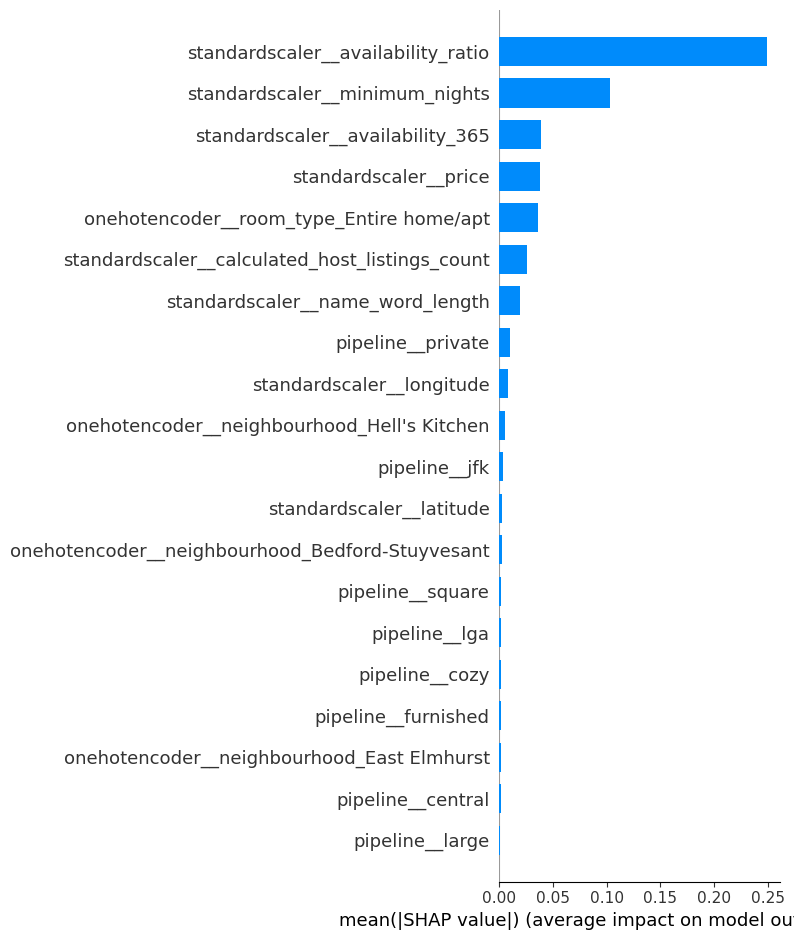

In [33]:
shap.summary_plot(train_shap_vals, X_train_processed, plot_type = "bar")

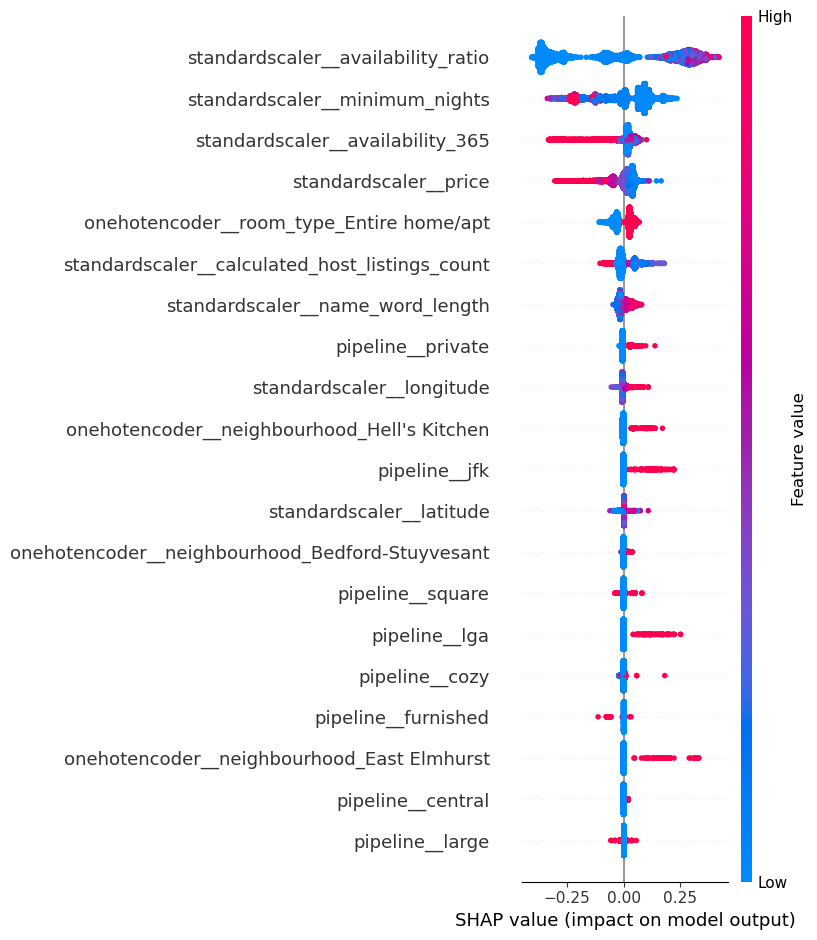

In [34]:
shap.summary_plot(train_shap_vals, X_train_processed)

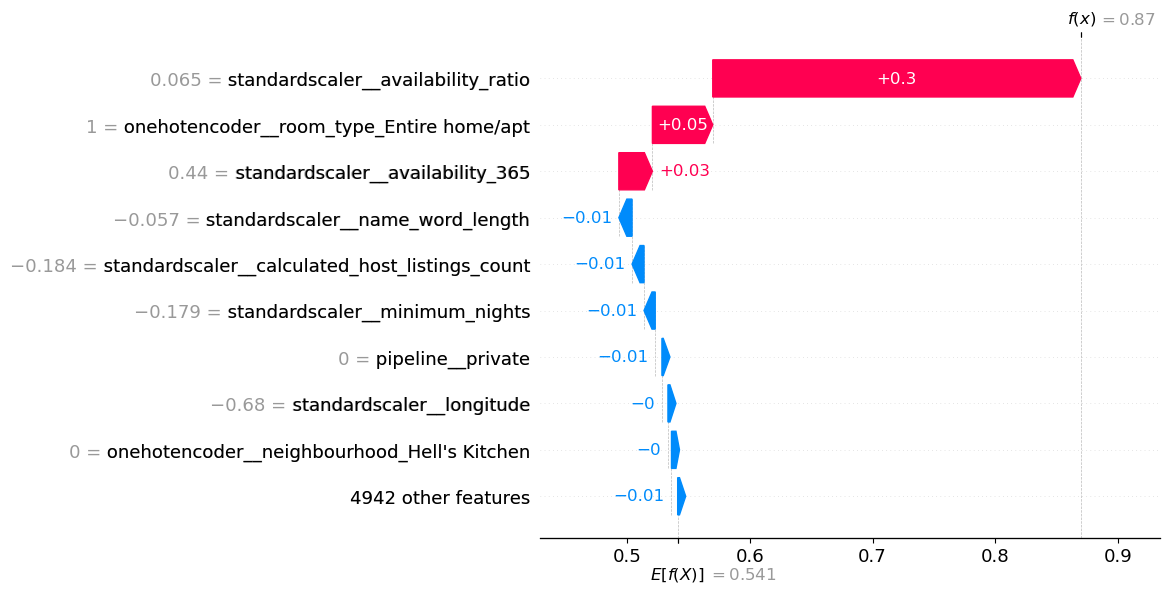

In [35]:
ex1_idx = 100
shap.plots.waterfall(train_shap_vals[ex1_idx])

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

2) My best model according to CV r2 mean score is GradientBoost (gb_pipe) with defauly hyperparameters. With this model, I achieved a mean r2 CV score of 0.4059. As shown below, scoring this model with my test set achieves an r2 score of 0.4041.

    These values are incredibly close, which suggests that my cross-validation workflow provided a reliable estimate of the model's generalization performance. We can be quite confident that our model would perform quite consistently when deployed on real-world data. 

    The moderate r2 (~0.4) score indicates the model explains roughly 40% of the variance in the log-transformed reviews_per_month. While the predictions capture some patterns in listing reviews per month as a proxy for relative popularity, there is still considerable unexplained variance in the original scale, meaning the model’s predictions for raw review counts are able to capture some patterns, but are still far from perfect.

    As for optimization bias, we can be relatively confident that this did not largely affect the scoring of our model, as our mean cv and test scores are very similar. Some small degree of optimization bias may exist if hyperparameters or preprocessing choices were tuned after observing CV performance. However, the close alignment between CV and test scores suggests that any such bias is likely minimal, and the model is not severely overfitted to the training data.

3) From the SHAP waterfall plots shown below, we can see how the model is able to start from a baseline prediction value (E[f(x)] = 0.544 in this case) and predict two very different target values based on the differing feature values.

- First, in example 3 (ex3_idx), we can see that the predicted target value was above the baseline prediction at f(x) = 1.075, which is +0.531 higher than the baseline value. `availability_ratio` induces the largest adjustment of +0.27 in the target prediction, followed by `minimum_nights` and `calculated_host_listings_count`, which drove +0.09 and +0.06 adjustments respectively. We can see that these 3 features alone singlehandedly accounted for the majority of the difference between f(x) and E[f(x)], as the least important 6144 features only contributed a net -0.01 to the overall prediction.
- Next, in example 4 (ex4_idx), we can see that the contrarily to the previous example, the predicted target value for this example was below the baseline prediction, with f(x) = 0.34. This is 0.204 lower than the baseline value. This time, we can see that `availability_ratio` and `minimum_nights` cause -0.21 and -0.18 respective changes in the target prediction, while `calculated_host_listings_count` still contributes to a +0.13 change in the target prediction. Likewise to the previous example, the net effect of these three features makes up the overwhelming majority of the feature-dependent shifts in the predicted value, where we see a net -0.01 adjustment derived from the 6144 least important features again. 

In [36]:
# fit gb_pipe on X_train, y_train_transformed
gb_pipe.fit(X_train, y_train_transformed)

,steps,"[('columntransformer', ...), ('gradientboostingregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('standardscaler', ...), ('onehotencoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
# score gb_pipe on X_test, y_test_transformed
gb_pipe.score(X_test, y_test_transformed)

0.4042294836322653

In [38]:
# create SHAP values, this breaks the golden rule but we've already scored above and we're just looking to analyze
# feature importances for a specific example, so it's not the end of the world
X_test_processed = preprocessor.fit_transform(X_test)

# convert sparse matrix to array
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()
    
model_test = gb_pipe.named_steps["gradientboostingregressor"]
model_test.fit(X_test_processed, y_test_transformed)

# create explainer with feature names
explainer_test = shap.TreeExplainer(model_test, feature_names = preprocessor.get_feature_names_out())
train_shap_vals = explainer_test(X_test_processed)

In [39]:
# idx examples for SHAP
ex3_idx = 100
ex4_idx = 251

In [40]:
shap.initjs()

In [41]:
test_shap_vals = explainer_test(X_test_processed)

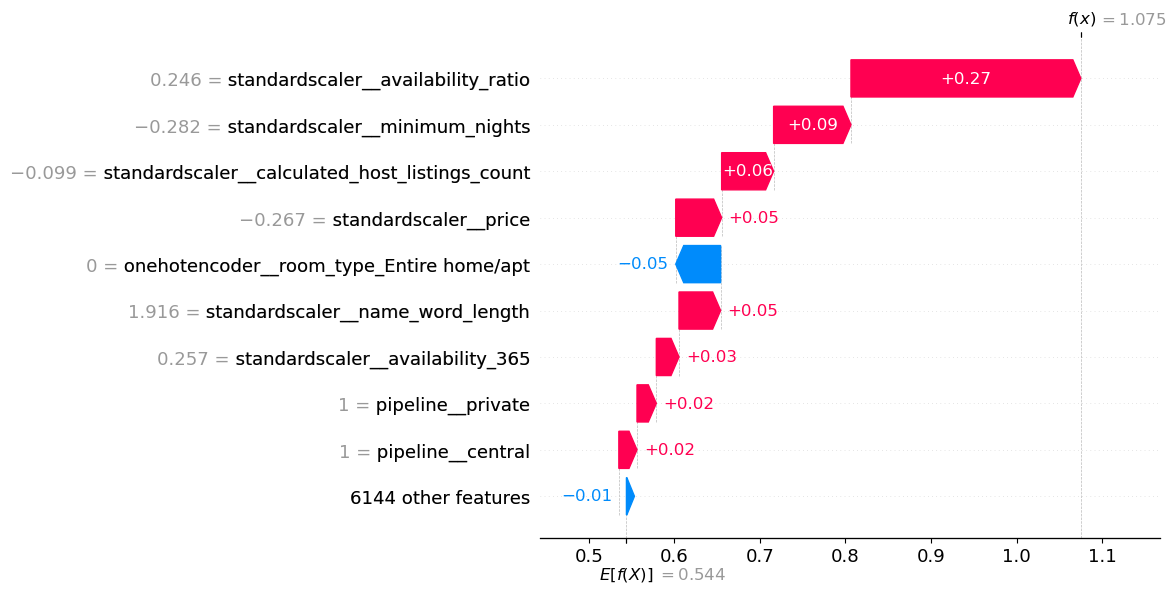

In [42]:
shap.plots.waterfall(test_shap_vals[ex3_idx])

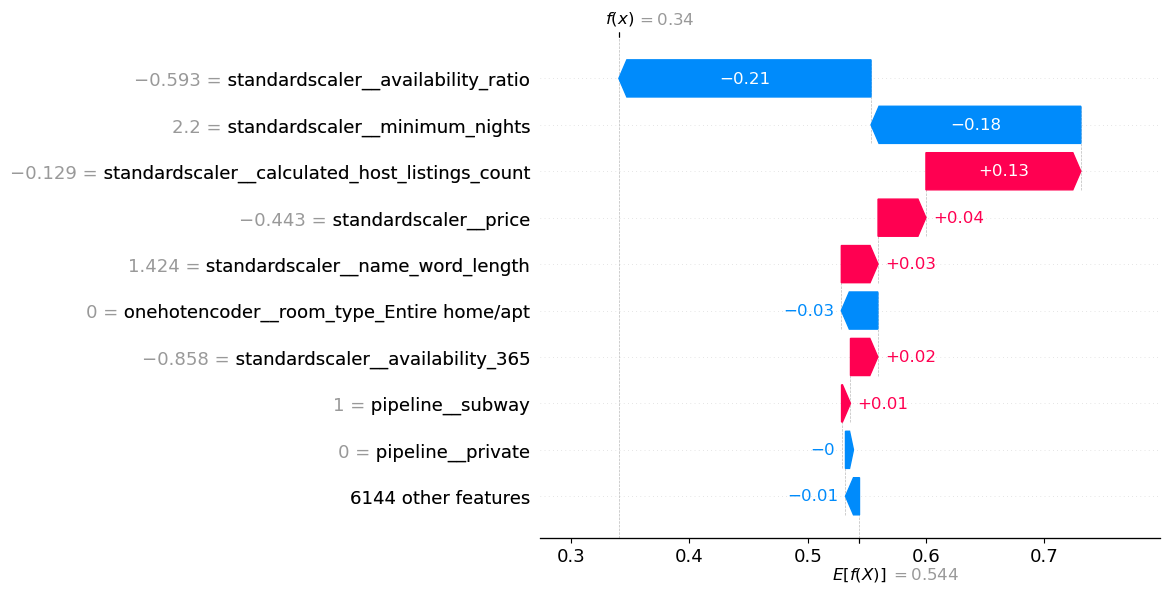

In [43]:
shap.plots.waterfall(train_shap_vals[ex4_idx])

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

| **Model**             | **Train R² (Mean)** | **Validation R² (Mean)** | **Std (Val R²)** | **Notes**                                                  |
| --------------------- | ------------------- | ------------------------ | ---------------- | ---------------------------------------------------------- |
| **Dummy Regressor**   | ~0.00               | ~0.00                    | 0.001            | Baseline — predicts mean only.                             |
| **Ridge (α=100)**     | 0.19                | 0.20                     | 0.01             | Best linear model; regularization improved generalization. |
| **SVR (RBF kernel)**  | 0.36                | 0.33                     | 0.02             | Captured some nonlinear structure, mild underfitting.      |
| **Random Forest**     | 0.89                | 0.37                     | 0.04             | Overfit training data; better validation R² than SVR.      |
| **Gradient Boosting** | 0.44                | **0.41**                 | **0.02**         | Best generalization; low variance and stable performance.  |


### Concluding Remarks

The Gradient Boosting Regressor model achieved the highest validation r2 (0.41), outperforming all other models, including the SVR, Ridge and Random Forest.

Applying a log transformation to the target improved stability and interpretability of predictions.

Feature engineering (availability ratio, name word length) modestly improved performance by capturing intuitive behavioral factors (booking flexibility, title appeal).

Feature selection (RFECV) did not improve performance, confirming that the Ridge model’s built-in regularization already mitigated redundancy.

Some of the most important features for prediction included the `availability_ratio` engineered feature and the `minimum_nights` a booking could be reserved for, and `price`.

Overall, the model captured meaningful, but limited, variance in listing popularity, suggesting external factors (e.g., seasonality, host behavior, listing photos) play a significant unobserved role.

### Future Improvements

| **Proposed Improvement**                           | **Rationale / Expected Benefit**                                                                                                                                                                           |
| -------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Hyperparameter tuning with larger search space** | The RandomizedSearchCV (n_iter=25) was constrained by computational limits. Expanding this (or using Bayesian optimization) could yield better parameter combinations, particularly for tree-based models. |
| **Stacked/ensemble models**                        | Combining Ridge, SVR, and Gradient Boosting predictions could reduce bias and variance, potentially improving validation R².                                                                               |
| **Text encoding**     | CountVectorizer was used, but more complex methods could capture richer meaning from listing titles.                                                                                                        |
| **Geospatial feature engineering**                 | Encoding latitude/longitude into neighborhood clusters or distance-to-centre features might help capture location-driven popularity effects.                                                               |
| **Temporal or host-level data**                    | Incorporating time-based data (e.g., month, season) or host reputation could significantly improve predictive performance.                                                                                 |


### Final Results

Final model: Gradient Boosting Regressor

Metric used: r2 (coefficient of determination)

Final test r2: 0.40 (approx., consistent with validation mean)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

My biggest takeaway from the supervised machine learning material is just how important the preprocessing and transformation steps are for developing an effective model. I recall earlier in the course we were told that 80% of the time in ML is spent on preprocessing, and I didn’t fully appreciate or recognize that until this project. Preprocessing and feature engineering — including scaling, encoding, transforming skewed features or targets, and selecting relevant features — can often improve model performance more than simply switching or optimizing the models themselves.

Additionally, it was really eye-opening how non-linear and iterative the modeling process is. Often, while working on a later step, you realize that something earlier in the pipeline needs to be adjusted or revisited. This taught me that building an effective model isn’t a strict stepwise process; it’s more like a feedback loop where analysis, experimentation, and adjustments go hand-in-hand.

Finally, through this project I gained a strong appreciation for the importance of computational efficiency when selecting models. For example, when I first started this project, I experimented with a k-nearest neighbors model and ran a cross-validation block overnight, only to find it still hadn’t finished in the morning. That experience highlighted that practical constraints, such as runtime and memory requirements, must be considered alongside predictive accuracy when choosing and tuning models, especially with larger datasets.

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)